1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

2. Load Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohit8527kmr7518/online-retail-customer-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 3.44M/3.44M [00:02<00:00, 1.20MB/s]

Extracting files...
Path to dataset files: C:\Users\eungl\.cache\kagglehub\datasets\rohit8527kmr7518\online-retail-customer-classification-dataset\versions\3


In [2]:
path = 'C:\\Users\\eungl\\.cache\\kagglehub\\datasets\\rohit8527kmr7518\\online-retail-customer-classification-dataset\\versions\\3'


In [8]:
%ls {path}

 Volume in drive C is OS
 Volume Serial Number is B48A-5F46

 Directory of C:\Users\eungl\.cache\kagglehub\datasets\rohit8527kmr7518\online-retail-customer-classification-dataset\versions\3

04/24/2026  09:25 AM    <DIR>          .
04/24/2026  09:25 AM    <DIR>          ..
04/24/2026  09:25 AM         8,135,306 retail_customer_segmentation.csv
               1 File(s)      8,135,306 bytes
               2 Dir(s)  137,581,686,784 bytes free


In [3]:
data = pd.read_csv(path + '\\retail_customer_segmentation.csv')
data.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment
0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,77.298393,2.0,Card,Semi-Urban,Occasional
1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,92.132565,2.0,Wallet,Urban,Occasional
2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,155.194768,1.0,UPI,Rural,Occasional
3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,113.917756,0.0,Wallet,Rural,High_Value
4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,50.123656,1.0,Card,Semi-Urban,Occasional


3. Data Inspection

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   annual_income          46925 non-null  float64
 3   months_active          50000 non-null  int64  
 4   avg_monthly_spend      47480 non-null  float64
 5   purchase_frequency     48021 non-null  float64
 6   avg_order_value        50000 non-null  float64
 7   discount_usage_rate    47451 non-null  float64
 8   return_rate            47513 non-null  float64
 9   browsing_time_minutes  46066 non-null  float64
 10  support_interactions   48012 non-null  float64
 11  payment_method         50000 non-null  object 
 12  region                 50000 non-null  object 
 13  customer_segment       50000 non-null  object 
dtypes: float64(8), int64(3), object(3)
memory usage: 5.3+ 

**Feature Description**
<div style="font-size: 0.8em;">
  
| Column Name | Type | Description |
| :--- | :--- | :--- |
| `customer_id` | Integer | Unique customer identifier. |
| `age` | Integer | Customer age (18–70). |
| `annual_income` | Float | Log-normally distributed income. |
| `months_active` | Integer | Number of months active. |
| `avg_monthly_spend` | Float | Average monthly expenditure. |
| `purchase_frequency` | Float | Average purchases per month. |
| `avg_order_value` | Float | `avg_monthly_spend` / (`purchase_frequency` + 1) |
| `discount_usage_rate` | Float | Proportion of purchases using discounts (0–1). |
| `return_rate` | Float | Proportion of return purchased (0-1). |
| `browsing_time_minutes` | Float | Avg browsing time per session. |
| `support_interactions` | Float | Support contacts (Poisson distributed). |
| `payment_method` | Categorical | `Card`, `UPI`, `Wallet`. |
| `region` | Categorical | `Urban`, `Semi-Urban`, `Rural`. |
| `customer_segment` | Categorical | Target variable. |

Most likely Interpretation:
- `puchase_frequency`: average purchases per month (total_purchase / months_active)
- `avg_order_value`: Not the traditional (sales/amt). It is an approximation of that, by taking the `avg_monthly_spend` / (`purchase_frequency` + 1)
- `discount_usage_rate`: Our of all purchases by a specific customer, what % of those used a discount?
- `return_rate`: Out of all purchases by a customer, what % of purchases were returned (for refund, exchange...)?
</div>



3.1. Statistical Analysis

Let's drop `customer_id`. It won't help us with analysis

In [11]:
data = data.drop(columns='customer_id')

In [17]:
quan_cols = data.select_dtypes(include='number').columns.tolist()
qual_cols = data.select_dtypes(exclude='number').columns.tolist()

print(f"Quantitative Columns ({len(quan_cols)}): {quan_cols} ")
print(f"Qualitative Columns ({len(qual_cols)}): {qual_cols}")

Quantitative Columns (10): ['age', 'annual_income', 'months_active', 'avg_monthly_spend', 'purchase_frequency', 'avg_order_value', 'discount_usage_rate', 'return_rate', 'browsing_time_minutes', 'support_interactions'] 
Qualitative Columns (3): ['payment_method', 'region', 'customer_segment']


In [12]:
# Quantitative Data Statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,50000.0,44.002820,15.269871,18.000000,31.000000,44.000000,57.000000,70.000000
annual_income,46925.0,44542.620904,30537.946035,2946.317892,24373.244554,36787.730010,55497.245522,530788.317921
months_active,50000.0,36.477480,20.787197,1.000000,18.000000,36.000000,55.000000,72.000000
avg_monthly_spend,47480.0,337.294238,204.627095,8.072298,192.074544,297.477404,439.112361,3026.342238
purchase_frequency,48021.0,4.910841,3.416115,0.017013,2.456867,4.158673,6.526903,67.682528
avg_order_value,50000.0,77.375915,70.531793,0.940393,32.018468,56.600351,98.832037,1289.427328
discount_usage_rate,47451.0,0.284358,0.159236,0.000534,0.160497,0.262591,0.387640,0.934655
return_rate,47513.0,0.148964,0.110508,0.000050,0.063938,0.123628,0.209612,0.830395
browsing_time_minutes,46066.0,61.781329,41.743394,0.236109,31.082283,52.679175,82.549571,406.813006
support_interactions,48012.0,1.494606,1.221280,0.000000,1.000000,1.000000,2.000000,9.000000


In [30]:
# Qualitative Data Statistics
for var in qual_cols:
    counts = data[var].value_counts()
    
    print(f"Distribution of {var}:")
    print(pd.DataFrame({
        'count': counts,
        'proportion': round(counts / counts.sum(), 2)
    }))
    print()

Distribution of payment_method:
                count  proportion
payment_method                   
Card            24953         0.5
UPI             14898         0.3
Wallet          10149         0.2

Distribution of region:
            count  proportion
region                       
Urban       24785         0.5
Semi-Urban  15212         0.3
Rural       10003         0.2

Distribution of customer_segment:
                  count  proportion
customer_segment                   
Occasional        22109        0.44
Regular           13455        0.27
Loyal              9163        0.18
High_Value         5273        0.11



<Axes: xlabel='payment_method', ylabel='count'>

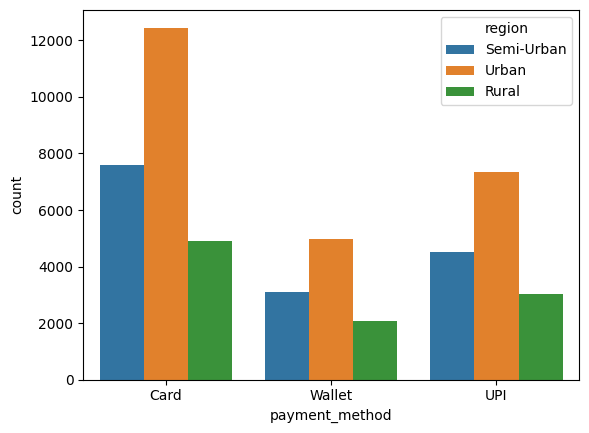

In [40]:
sns.countplot(data, hue='region', x='payment_method')

<Axes: xlabel='return_rate', ylabel='Count'>

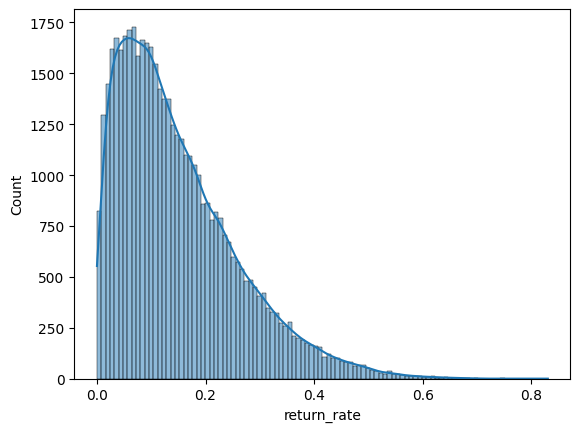

In [18]:
sns.histplot(data['return_rate'], kde=True)

<Axes: xlabel='purchase_frequency', ylabel='Count'>

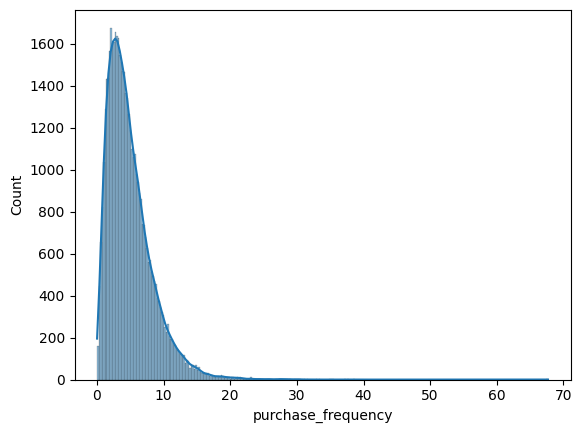

In [4]:
sns.histplot(data['purchase_frequency'], kde=True)

In [5]:
data['purchase_frequency'].describe()

count    48021.000000
mean         4.910841
std          3.416115
min          0.017013
25%          2.456867
50%          4.158673
75%          6.526903
max         67.682528
Name: purchase_frequency, dtype: float64

<Axes: xlabel='support_interactions', ylabel='Count'>

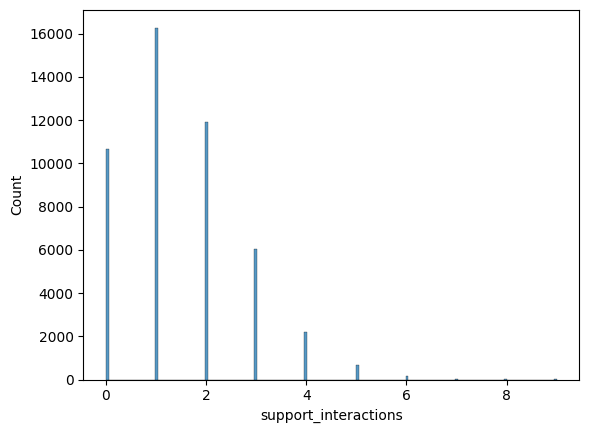

In [19]:
sns.histplot(data['support_interactions'])

In [6]:
data.columns

Index(['customer_id', 'age', 'annual_income', 'months_active',
       'avg_monthly_spend', 'purchase_frequency', 'avg_order_value',
       'discount_usage_rate', 'return_rate', 'browsing_time_minutes',
       'support_interactions', 'payment_method', 'region', 'customer_segment'],
      dtype='object')

<Axes: xlabel='customer_segment', ylabel='discount_usage_rate'>

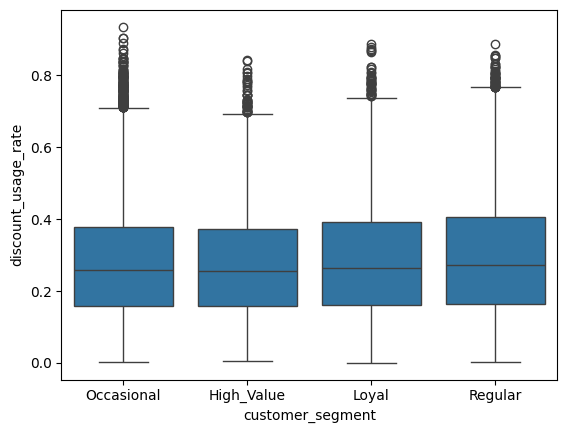

In [9]:
sns.boxplot(data, x='customer_segment', y='discount_usage_rate')